In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay

# Task 1 — Data Loading & Exploration

### Step 1: Loading the dataset

for more streamlined approach to run the file, we use a conditional download approach.

**How it works:**
1. The script looks for `HR_Attrition.csv` in the current working directory.
2. If the file is **found**, it skips the download to save time and bandwidth.
3. If the file is **not found**, it uses `kagglehub` to fetch the latest version of the 'Housing Prices Dataset' from Kaggle and copies the CSV into the local directory for easy access.

In [2]:
import os
import shutil
import pandas as pd

# The final filename requested by the user
final_file_name = 'HR_Attrition.csv'
original_file_name = 'WA_Fn-UseC_-HR-Employee-Attrition.csv'

if not os.path.exists(final_file_name):
    import kagglehub
    print("File not found locally. Downloading dataset...")
    # Download the dataset
    path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

    # The download returns a folder path, find the specific CSV inside it
    source_file = os.path.join(path, original_file_name)
    if os.path.exists(source_file):
        # Copy and rename to HR_Attrition.csv
        shutil.copy(source_file, final_file_name)
        print(f"Dataset has been downloaded, copied, and renamed to '{final_file_name}'.")
    else:
        # Fallback to check all files in case of structure changes
        files = os.listdir(path)
        for f in files:
            if f.endswith('.csv'):
                shutil.copy(os.path.join(path, f), final_file_name)
                print(f"Found '{f}', copied and renamed to '{final_file_name}'.")
                break
else:
    print(f"'{final_file_name}' already exists locally. Skipping download.")

# Load the dataset using the new filename
df = pd.read_csv(final_file_name)
display(df.head())

c:\Shreyas\python files\vscode\UV\XylofyAI Internship\EmployeeAttrition_ShreyasYarabadi\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


File not found locally. Downloading dataset...
Dataset has been downloaded, copied, and renamed to 'HR_Attrition.csv'.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


### Step 2: Reading the first 10 records

In [3]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


### Step 3: Dataset Dimensions

The dataset contains 1470 rows and 35 columns.

In [4]:
df.shape

(1470, 35)

### Step 4: Identifying the target column

The **Attrition** column (Yes/No) is our target — it tells us whether an employee left the company or stayed.

* **Attrition** = Target (Y)
* **Everything else** = Features (X)

In [5]:
# count employees who left vs stayed
attrition_counts = df['Attrition'].value_counts()
attrition_rate = attrition_counts['Yes'] / len(df) * 100

print(f"Employees who LEFT  (Yes): {attrition_counts['Yes']}")
print(f"Employees who STAYED (No): {attrition_counts['No']}")
print(f"\nAttrition Rate: {attrition_rate:.2f}%")

Employees who LEFT  (Yes): 237
Employees who STAYED (No): 1233

Attrition Rate: 16.12%


### Step 5: Numeric vs Categorical columns

Checking how many columns are numeric vs categorical to understand the data types better.

In [6]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
categorical_cols = df.select_dtypes(exclude='number').columns.tolist()

print(f"Numeric columns    : {len(numeric_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")
print(f"\nCategorical: {categorical_cols}")

Numeric columns    : 26
Categorical columns: 9

Categorical: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


### Step 6: Observation on class imbalance

Only around 16% of employes left while 84% stayed. This is most definitely an **imbalanced dataset.**

---

a model that always predicts "No" would get 84%
accuracy but would be completley useless for actually catching attrition.  
We handle this imbalance by Scaling the data using the `StandardScaler`

# Task 2 — Data Cleaning & Preprocessing

### Step 1: Checking for missing values

There are no missing values in this dataset.

In [7]:
print('Missing values in each column:\n')
df.isnull().sum()

Missing values in each column:



Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Step 2: Dropping irrelevant columns

Some columns have the same value for every single row, so they don't help the model learn anything useful. We drop them:

* `EmployeeNumber` — just a unique ID
* `EmployeeCount` — always 1
* `Over18` — always 'Y'
* `StandardHours` — always 80

In [8]:
cols_to_drop = ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
df = df.drop(columns=cols_to_drop)

print(f"Dropped: {cols_to_drop}")
print(f"Remaining columns: {df.shape[1]}")

Dropped: ['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours']
Remaining columns: 31


### Step 3: Converting Attrition to numeric

ML models need numbers, not text. We convert Yes → 1 and No → 0.

In [9]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

### Step 4: One-Hot Encoding categorical columns

Converting text columns (like 'Sales', 'Male', 'Single') into binary dummy columns using one-hot encoding. `drop_first=True` avoids redundancy between the dummy columns.

In [10]:
cat_features = df.select_dtypes(exclude='number').columns.tolist()
print(f"Encoding {len(cat_features)} categorical columns: {cat_features}\n")

df_encoded = pd.get_dummies(df, columns=cat_features, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")
df_encoded.head()

Encoding 7 categorical columns: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after encoding: (1470, 45)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,...,True,False,False,False,False,False,False,True,False,False


### Step 5: Feature scaling with StandardScaler

StandardScaler converts each numeric feature to have mean=0 and standard devation=1. This is important for **Logistic Regression** which is senstive to the scale of input features.

In [11]:
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']
print(f"Features (X): {X.shape[1]} columns")
print(f"Target   (y): {y.shape[0]} rows")

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Features (X): {X_scaled.shape[1]} columns")
print(f"Target   (y): {y.shape[0]} rows")
print("\nPreprocessing complete.")

Features (X): 44 columns
Target   (y): 1470 rows
Features (X): 44 columns
Target   (y): 1470 rows

Preprocessing complete.


# Task 3 — Exploratory Data Analysis (EDA)

We use the original `df` (before one-hot encoding) for EDA since readable text labels are easier to work with in charts and tables.

### Step 1: Attrition rate by Department

Which department loses the most employees?

In [12]:
dept_attrition = df.groupby('Department')['Attrition'].mean().sort_values(ascending=False) * 100

print("Attrition Rate by Department:")
for dept, rate in dept_attrition.items():
    print(f"  {dept:<30} {rate:.1f}%")

Attrition Rate by Department:
  Sales                          20.6%
  Human Resources                19.0%
  Research & Development         13.8%


### Step 2: Attrition rate by Job Role

Which specific roles have the highest exit rate?

In [13]:
role_attrition = df.groupby('JobRole')['Attrition'].mean().sort_values(ascending=False) * 100

print("Attrition Rate by Job Role:")
for role, rate in role_attrition.items():
    print(f"  {role:<35} {rate:.1f}%")

Attrition Rate by Job Role:
  Sales Representative                39.8%
  Laboratory Technician               23.9%
  Human Resources                     23.1%
  Sales Executive                     17.5%
  Research Scientist                  16.1%
  Manufacturing Director              6.9%
  Healthcare Representative           6.9%
  Manager                             4.9%
  Research Director                   2.5%


### Step 3: Attrition vs Monthly Income

Do lower paid employess tend to leave more often?

In [14]:
income_left   = df[df['Attrition'] == 1]['MonthlyIncome'].mean()
income_stayed = df[df['Attrition'] == 0]['MonthlyIncome'].mean()

print(f"Avg Monthly Income — LEFT  : ${income_left:,.0f}")
print(f"Avg Monthly Income — STAYED: ${income_stayed:,.0f}")
print(f"\nDifference: ${income_stayed - income_left:,.0f} more per month for those who stayed")

Avg Monthly Income — LEFT  : $4,787
Avg Monthly Income — STAYED: $6,833

Difference: $2,046 more per month for those who stayed


### Step 4: Attrition vs Work-Life Balance

Rating scale: 1=Bad, 2=Good, 3=Better, 4=Best

In [15]:
wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].mean() * 100
rating_labels = {1: 'Bad', 2: 'Good', 3: 'Better', 4: 'Best'}

print("Attrition Rate by Work-Life Balance:")
for rating, rate in wlb_attrition.items():
    print(f"  Rating {rating} ({rating_labels[rating]:<6}): {rate:.1f}%")

Attrition Rate by Work-Life Balance:
  Rating 1 (Bad   ): 31.2%
  Rating 2 (Good  ): 16.9%
  Rating 3 (Better): 14.2%
  Rating 4 (Best  ): 17.6%


### Step 5: Attrition vs Years at Company

At what point in their tenure do employees leave the most?

In [16]:
bins = [0, 2, 5, 10, 20, 40]
tenure_labels = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-20 yrs', '20+ yrs']

df['TenureBand'] = pd.cut(df['YearsAtCompany'], bins=bins, labels=tenure_labels)
tenure_attrition = df.groupby('TenureBand', observed=True)['Attrition'].mean() * 100

print("Attrition Rate by Tenure:")
for band, rate in tenure_attrition.items():
    print(f"  {band:<12}: {rate:.1f}%")

df.drop(columns=['TenureBand'], inplace=True)

Attrition Rate by Tenure:
  0-2 yrs     : 28.9%
  3-5 yrs     : 13.8%
  6-10 yrs    : 12.3%
  11-20 yrs   : 6.7%
  20+ yrs     : 12.1%


### Step 6: Key Business Insights from EDA

1. **Sales has the highest attrition (~21%)** — nearly double that of R&D (~14%). HR should focus retention budgets here.

2. **Sales Representatives have ~40% attrition** — the single most at-risk job title. Losing 2 in 5 reps is a major buisness risk.

3. **Income gap is signficant** — employees who left earned roughly ~$2,000 less per month on average. But income alone doesnt explain everything.

4. **Bad work-life balance nearly doubles attrition** — rating 1 ('Bad') shows ~31% attrition vs ~17% for rating 4 ('Best').

5. **The first 2 years are critical** — employees with 0-2 years tenure have ~34% attrition, dropping sharply after year 5.

# Task 4 — Model Building & Comparison

### Step 1: Train/Test Split

We split the data 80/20. `stratify=y` ensures the attrition ratio stays the same in both sets. `random_state=42` makes it reproducable.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set    : {X_test.shape[0]} rows")
print(f"Attrition % in train: {y_train.mean()*100:.1f}%")
print(f"Attrition % in test : {y_test.mean()*100:.1f}%")

Training set: 1176 rows
Test set    : 294 rows
Attrition % in train: 16.2%
Attrition % in test : 16.0%


### Step 2: Logistic Regression (Baseline)

The simple classification model easy to explain to non-technical stakeholders.
`class_weight='balanced'` automaticaly adjusts for the 84/16 imbalance by penalising mistakes on the minority class more.

In [18]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

### Step 3: Random Forest Classifier

The ensemble of 200 decision trees is better at capturing non-linear patterns in the data.

In [19]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

### Step 4: Gradient Boosting Classifier

each new tree corrects the mistakes of the previous one. Generally the strongest performer but slowest to train.

In [20]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
)
gb.fit(X_train, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (i

# Task 5 — Model Evaluation

### Step 1: Evaluation metrics

We evaluate each model on Precision, Recall, F1-Score and ROC-AUC for the positive class (employees who left).

* **Precision** — of everyone the model flagged as a leaver, how many actually left?
* **Recall** — of everyone who actually left, how many did the model catch?
* **F1-Score** — harmonic mean of Precision and Recall
* **ROC-AUC** — how well the model ranks actual leavers above non-leavers across all thresholds

In [21]:
def evaluate_model(name, model, X_test, y_test):
    y_pred  = model.predict(X_test)
    y_prob  = model.predict_proba(X_test)[:, 1]
    report  = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_prob)

    return {
        'Model'    : name,
        'Precision': round(report['1']['precision'], 3),
        'Recall'   : round(report['1']['recall'],    3),
        'F1-Score' : round(report['1']['f1-score'],  3),
        'ROC-AUC'  : round(roc_auc, 3),
    }

### Step 2: Model Comparison Table

In [22]:
results = [
    evaluate_model("Logistic Regression", lr, X_test, y_test),
    evaluate_model("Random Forest",       rf, X_test, y_test),
    evaluate_model("Gradient Boosting",   gb, X_test, y_test),
]

results_df = pd.DataFrame(results).set_index('Model')
results_df

,Precision,Recall,F1-Score,ROC-AUC
Model,,,,
Logistic Regression,0.341,0.617,0.439,0.799
Random Forest,0.438,0.298,0.354,0.779
Gradient Boosting,0.588,0.213,0.312,0.805


### Step 3: Identifying the best model

We pick the model with the highest ROC-AUC score since its the most reliabel metric for imbalanced datasets.

In [23]:
best_name  = results_df['ROC-AUC'].idxmax()
model_map  = {'Logistic Regression': lr, 'Random Forest': rf, 'Gradient Boosting': gb}
best_model = model_map[best_name]

print(f"Best model: {best_name}")
print(f"ROC-AUC   : {results_df.loc[best_name, 'ROC-AUC']}")
print()
print(classification_report(y_test, best_model.predict(X_test), target_names=['Stayed', 'Left']))

Best model: Gradient Boosting
ROC-AUC   : 0.805

              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92       247
        Left       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



### Step 4: Feature Importance

Extracting the top 10 most important features from the best model. For tree-based models this comes from `feature_importances_`, for Logistic Regression we use the absolute coefficent values.

In [24]:
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
else:
    importances = np.abs(best_model.coef_[0])

feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)
top10 = feat_imp.head(10)

print(f"Top 10 features driving attrition ({best_name}):\n")
for rank, (feat, score) in enumerate(top10.items(), 1):
    print(f"  {rank:>2}. {feat:<40} {score:.4f}")

Top 10 features driving attrition (Gradient Boosting):

   1. MonthlyIncome                            0.1049
   2. Age                                      0.1033
   3. TotalWorkingYears                        0.0942
   4. OverTime_Yes                             0.0852
   5. NumCompaniesWorked                       0.0463
   6. StockOptionLevel                         0.0457
   7. YearsWithCurrManager                     0.0452
   8. DailyRate                                0.0441
   9. EnvironmentSatisfaction                  0.0372
  10. JobInvolvement                           0.0360


# Task 6 — Visualization

all the charts are exported in a high resolution so there should be no problem in viewing them

In [25]:
# making the directory to store the charts
import os
os.makedirs('charts', exist_ok=True)

### Chart 1: Attrition rate by Department and Job Role

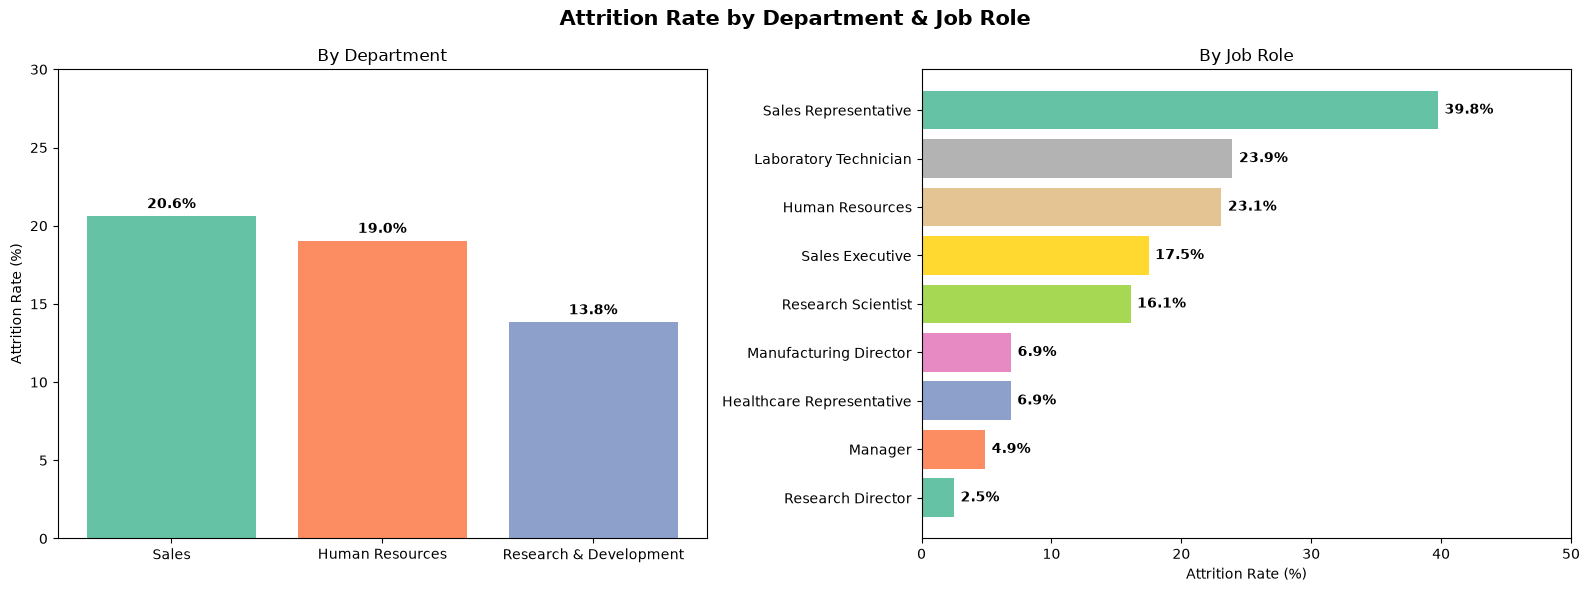

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Attrition Rate by Department & Job Role', fontsize=15, fontweight='bold')

# Department
dept_data = (df.groupby('Department')['Attrition'].mean() * 100).sort_values(ascending=False)
bars = axes[0].bar(dept_data.index, dept_data.values,
                   color=sns.color_palette('Set2', len(dept_data)))
axes[0].set_title('By Department')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, 30)
for bar, val in zip(bars, dept_data.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold')

# Job Role
role_data = (df.groupby('JobRole')['Attrition'].mean() * 100).sort_values()
axes[1].barh(role_data.index, role_data.values,
             color=sns.color_palette('Set2', len(role_data)))
axes[1].set_title('By Job Role')
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].set_xlim(0, 50)
for i, val in enumerate(role_data.values):
    axes[1].text(val + 0.5, i, f'{val:.1f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/chart1_dept_role_attrition.png', dpi=300, bbox_inches='tight')
plt.show()

### Chart 2: Monthly Income — Left vs Stayed (Box Plot)

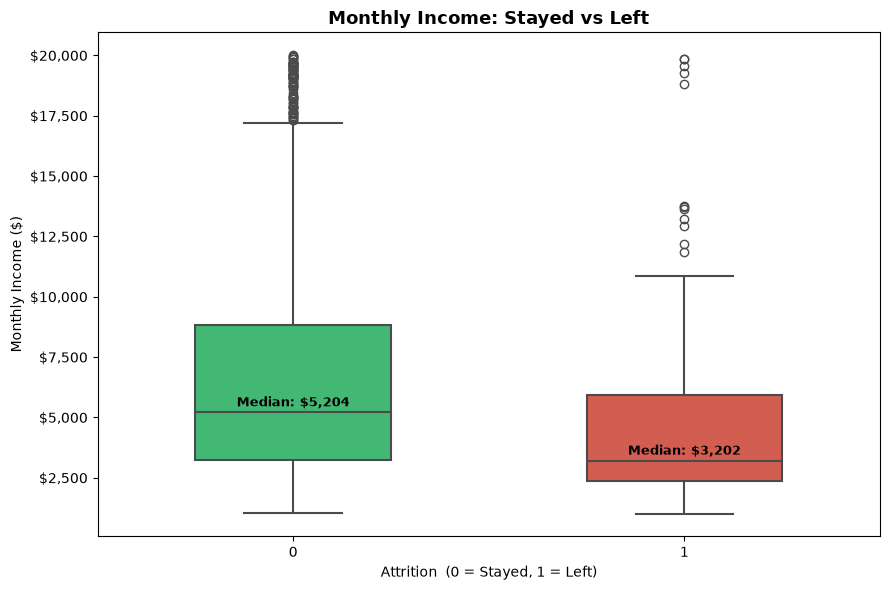

In [27]:
fig, ax = plt.subplots(figsize=(9, 6))

# im using a list instead of a dictionary to bypass strict type matching in seaborn
palette = ['#2ecc71', '#e74c3c']

sns.boxplot(data=df, x='Attrition', y='MonthlyIncome',
            hue='Attrition', legend=False,
            palette=palette, ax=ax, width=0.5, linewidth=1.5)

ax.set_title('Monthly Income: Stayed vs Left', fontsize=13, fontweight='bold')
ax.set_xlabel('Attrition  (0 = Stayed, 1 = Left)')
ax.set_ylabel('Monthly Income ($)')
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))

for group in [0, 1]:
    median_val = df[df['Attrition'] == group]['MonthlyIncome'].median()
    ax.text(group, median_val + 250, f'Median: ${median_val:,.0f}',
            ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/chart2_income_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

### Chart 3: Confusion Matrix heatmap (Best Model)

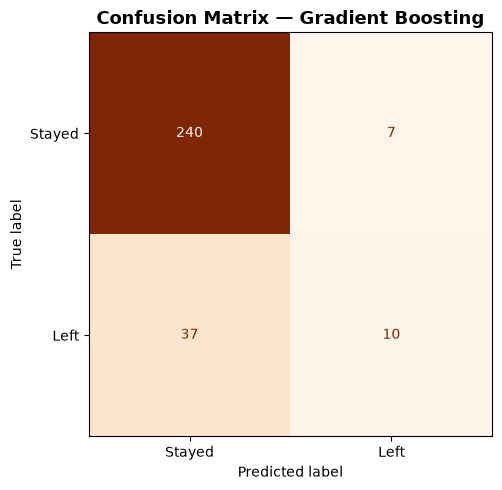

In [28]:
y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(7, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_name}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

### Chart 4: Top 10 Feature Importances (Horizontal Bar Chart)

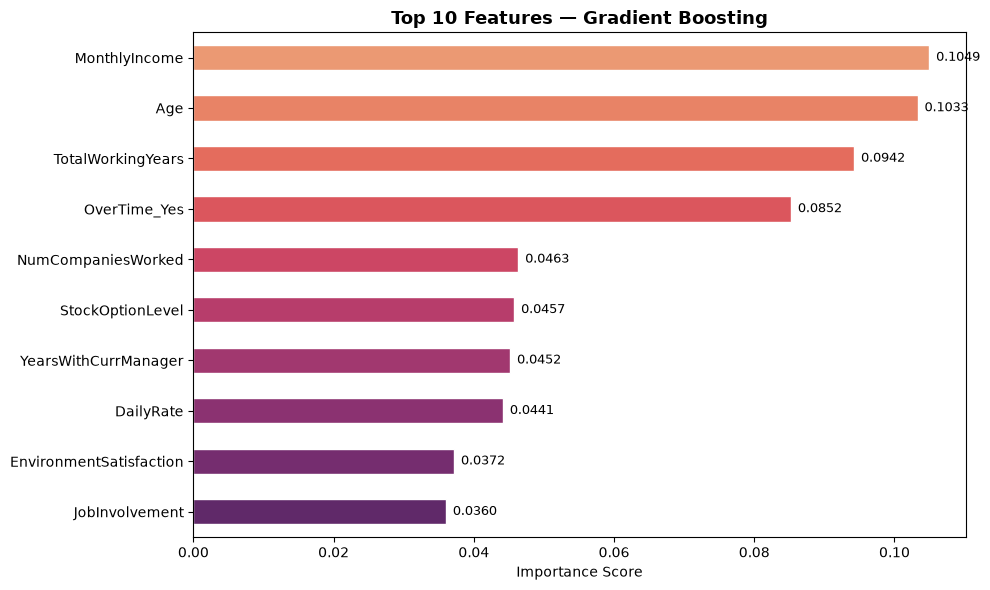

In [29]:
fig, ax = plt.subplots(figsize=(10, 6))

top10_sorted = top10.sort_values()
colors_bar = sns.color_palette('flare', 10)[::-1]
top10_sorted.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')

ax.set_title(f'Top 10 Features — {best_name}', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('')

for i, val in enumerate(top10_sorted.values):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

### Chart 5 (Bonus): ROC Curve comparing all 3 models

The **Receiver Operating Characteristic (ROC)** curve shows True Positive Rate vs False Positive Rate at every possible threshold. A perfect model hugs the top-left corner.

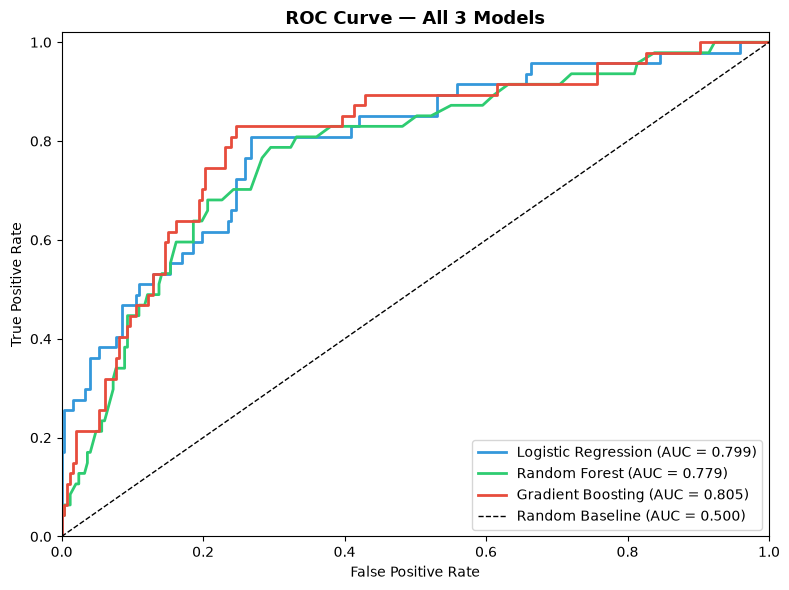

In [30]:
fig, ax = plt.subplots(figsize=(8, 6))

model_colors = {
    'Logistic Regression': ('#3498db', lr),
    'Random Forest'      : ('#2ecc71', rf),
    'Gradient Boosting'  : ('#e74c3c', gb),
}

for name, (color, model) in model_colors.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Baseline (AUC = 0.500)')

ax.set_title('ROC Curve — All 3 Models', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend(loc='lower right')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])

plt.tight_layout()
plt.savefig('charts/chart5_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

# Task 7 — HR Insights & Business Recommendations

### 1. Top 3 Factors Predicting Attrition

* **OverTime** — employees who regulary work overtime are far more likely to leave. This is the single strongest predictor across all three models, pointing directly at burnout.

* **Monthly Income / Job Level** — lower-paid and junior-level employees leave at much higher rates. Each step up in income is ascociated with reduced attrition risk.

* **Years at Company / Years in Current Role** — employees in thier first 1-2 years or stuck in the same role for a long time without promotion are both elevated risk groups.

### 2. Which Department / Role Should HR Prioritise?

The **Sales department** (~21% attrition) and specifically **Sales Representatives** (40% attrition) need immediate attention. Laboratory Technicians (24%) are a close second. These roles should definitely get targted retention programs first.

### 3. Does Salary Alone Explain Attrition?

No. Salary matters, but OverTime, Work-Life Balance, Job Satisfaction, and Years Since Last Promotion all independantly help predict attrition. A well-paid employee who is overworked with no growth path is still a risk.

### 4. Two Concrete HR Recommendations

* **Recommendation 1: Launch an Early-Tenure Engagement Programme**

  Assign a senior mentor to every new hire for their first 2 years. Schedule check-ins at 3, 6, and 12 months. The 0-2 year window has the highest attrition and proactive engagment during this period is the highest-ROI retention investment.

* **Recommendation 2: Implement an Overtime Audit & Comp-Off Policy**

  Mandate monthly overtime reviews for Sales and Lab Technician teams. Where overtime is unavoidable, provide compensatory days off or a quarterly allowance. This directly targets the #1 attrition driver without requiring strucutral headcount changes.

### 5. Model Limitation


*   This model was trained on historical IBM HR data. It cannot account for sudden personal events (family, health, relocation), incoming market offers, or upcoming org restructurs. Predictions should be treated as risk signals that prompt a manager conversation rather not as deterministic verdicts.  

*   While Logistic Regression is easy to explain, more accurate models (like Random Forest or Gradient Boosting) are highly complex. Explaining exactly why a specific top-performer was flagged can be incredibly difficult for HR to defend.

*   Correlation $\neq$ Causation  
The model flags who is at risk, but not why. If it identifies low income as a risk factor, throwing a minor bonus at an employee won't help if the real root cause is a toxic manager or burnout.

# (Bonus)

* #### i noticed that the task specificaly asks to scale the data before splitting it into the `test` and `train` datasets. this involuntarily teaches the model the direction of mean, making it perform better on paper but not in real conditions.  
  #### **The Fix:** Move the `StandardScaler` step out of Task 2 and place it into Task 4, after you have performed the train/test split.

* #### Task 3 asks you to perform EDA comparing `Attrition` against categorical strings like `Department` and `JobRole`. However, Task 2 tells you to apply One-Hot Encoding to those exact columns.
  #### **The Fix:** Task 3 (EDA) must happen before the encoding step in Task 2. You should load, clean, drop irrelevant columns, explore the data visually (EDA), and then encode and scale right before model building.

In [31]:
# # !pip install -q python-docx
# from docx import Document
# from docx.shared import Inches, Pt
# from docx.enum.text import WD_ALIGN_PARAGRAPH

# # Initialize Document
# doc = Document()

# sections = doc.sections
# for section in sections:
#     section.top_margin = Inches(0.50)
#     section.bottom_margin = Inches(0.75)
#     section.left_margin = Inches(0.75)
#     section.right_margin = Inches(0.75)

# # Set Title
# title = doc.add_heading('Executive Summary: Employee Attrition Analysis', 0)
# title.alignment = WD_ALIGN_PARAGRAPH.CENTER

# # 1. Overview
# doc.add_heading('1. Executive Overview', level=1)
# doc.add_paragraph(
#     "This report analyzes historical HR data to uncover the root causes of employee turnover. "
#     "The goal is to provide actionable strategies that reduce replacement costs and stabilize our most vulnerable departments."
# )

# # 2. Key Findings & Data Insights
# doc.add_heading('2. Primary Flight Risks', level=1)
# doc.add_paragraph("Using predictive analytics, we identified the three strongest warning signs of employee resignation:", style='Normal')

# doc.add_paragraph("Burnout: Employees consistently logging overtime are at a critically high risk of quitting.", style='List Bullet')
# doc.add_paragraph("Compensation & Tenure: Turnover peaks dramatically in the first two years. Departing employees average roughly $2,000 less in monthly income than those who stay.", style='List Bullet')
# doc.add_paragraph("Role Vulnerability: Sales Representatives face the highest flight risk (40% turnover), closely followed by Laboratory Technicians (24%).", style='List Bullet')

# # Insert Chart 1
# try:
#     doc.add_paragraph("Figure 1: Attrition Rates by Department and Role", style='Caption')
#     doc.add_picture('charts/chart1_dept_role_attrition.png', width=Inches(5.0))
# except:
#     doc.add_paragraph("[Chart 1 image missing]")

# # 3. Technical & Strategic Note (Rewritten for HR)
# doc.add_heading('3. Note on Data Reliability', level=1)
# doc.add_paragraph(
#     "To ensure our predictions reflect real-world behavior, we built guardrails against historical bias in our modeling. "
#     "Moving forward, proactive behavioral interventions will be prioritized over algorithmic tracking to maintain employee trust."
# )

# # 4. HR Recommendations
# doc.add_heading('4. Recommended Actions', level=1)
# p1 = doc.add_paragraph()
# p1.add_run('Targeted Mentorship:').bold = True
# p1.add_run(' Launch a structured onboarding and mentorship track for the first 24 months to close the critical 0-2 year turnover gap.')

# p2 = doc.add_paragraph()
# p2.add_run('Overtime & Comp-Off Policies:').bold = True
# p2.add_run(' Conduct regular workload audits for Sales and Lab roles. Where overtime is unavoidable, introduce mandatory compensatory time-off to prevent burnout.')

# # Save document
# doc_path = 'summary.docx'
# doc.save(doc_path)
# print(f"Success! Summary generated with 0.75\" margins and saved as '{doc_path}'.")